# 16 GLM Representation-Specific Models, Diagnostics, and Holdout Validation

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

GENDER_CATEGORIES = ["MM", "MW", "WM", "WW"]

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
BC_DATA_DIR = PROJECT_ROOT / "outputs" / "04_bibliographic_coupling_network" / "data"
COCIT_DATA_DIR = PROJECT_ROOT / "outputs" / "03_cocitation_network" / "data"

NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "16_glm_models"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / "tables"
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / "data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.20
RANDOM_STATE = 42
ALPHA = 1.0
MODEL_LABELS = {
    "M1_structural": "M1",
    "M2_direct_citation_network": "M2",
    "M3_bibliographic_coupling": "M3",
    "M4_cocitation": "M4",
    "M5_all_network_features": "M5",
}
SLICE_ORDER = ["All→CS", "CS→CS"]

## Functions

In [2]:
def standardize_edges(edges):
    out = edges[["citing_paper_id", "cited_paper_id"]].copy()
    out["citing_paper_id"] = out["citing_paper_id"].astype(str)
    out["cited_paper_id"] = out["cited_paper_id"].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / "papers_final.pkl")
    cs_papers = pd.read_pickle(PROCESSED_DIR / "cs_papers_final.pkl")
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_final.pkl"))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_all_to_cs_final.pkl"))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_cs_to_cs_final.pkl"))
    papers["id"] = papers["id"].astype(str)
    cs_papers["id"] = cs_papers["id"].astype(str)
    return papers, cs_papers, all_edges, all_to_cs, cs_to_cs

def add_observed(papers_df, edges, col="observed"):
    counts = edges["cited_paper_id"].value_counts()
    out = papers_df.copy()
    out[col] = out["paper_id"].map(counts).fillna(0).astype(float)
    return out

def make_structural_base(cs_papers):
    x = cs_papers[cs_papers["first_last_cat"].isin(GENDER_CATEGORIES)].copy()
    x = x.rename(columns={"id": "paper_id", "first_last_cat": "gender_cat"})
    x["paper_id"] = x["paper_id"].astype(str)
    x["log1p_n_refs"] = np.log1p(pd.to_numeric(x["n_refs"], errors="coerce").fillna(0).clip(lower=0))
    x["decade"] = x["decade"].astype("string").fillna("Unknown")
    x["primary_subfield"] = x["primary_subfield"].astype("string").fillna("Unknown")
    x["venue_rank_clean"] = x["venue_rank_clean"].astype("string").fillna("N/A")
    return x

def fit_poisson_expected(df, outcome_col, categorical_features, numeric_features, expected_col, alpha=1.0):
    x = df.copy()
    for c in categorical_features:
        x[c] = x[c].astype("string").fillna("Unknown")
    for c in numeric_features:
        x[c] = pd.to_numeric(x[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X = x[categorical_features + numeric_features]
    y = x[outcome_col].astype(float).to_numpy()
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ])
    pipe = Pipeline([
        ("preprocess", pre),
        ("model", PoissonRegressor(alpha=alpha, max_iter=300, tol=1e-6)),
    ])
    pipe.fit(X, y)
    raw = np.clip(pipe.predict(X), 1e-12, None)
    scale = y.sum() / raw.sum()
    x[expected_col] = raw * scale
    return x, pipe, scale

def aggregate_glm_oe(df, outcome_col, expected_col, model_name, citation_slice):
    out = (
        df.groupby("gender_cat")
        .agg(
            n_papers=("paper_id", "nunique"),
            observed_citations=(outcome_col, "sum"),
            expected_citations=(expected_col, "sum"),
        )
        .reindex(GENDER_CATEGORIES)
        .reset_index()
    )
    out["oe_ratio"] = out["observed_citations"] / out["expected_citations"].replace(0, np.nan)
    out["pct_diff_from_expected"] = (out["oe_ratio"] - 1) * 100
    out["model"] = model_name
    out["citation_slice"] = citation_slice
    return out

def standardize_bc(net):
    out = net[["paper_i", "paper_j", "shared_references"]].rename(
        columns={"shared_references": "weight"}
    ).copy()
    out["paper_i"] = out["paper_i"].astype(str)
    out["paper_j"] = out["paper_j"].astype(str)
    out["weight"] = pd.to_numeric(out["weight"], errors="coerce")
    return out[out["weight"].gt(0) & out["paper_i"].ne(out["paper_j"])].drop_duplicates(["paper_i", "paper_j"])

def standardize_cocit(net):
    out = net[["paper_a", "paper_b", "shared_citers"]].rename(
        columns={"paper_a": "paper_i", "paper_b": "paper_j", "shared_citers": "weight"}
    ).copy()
    out["paper_i"] = out["paper_i"].astype(str)
    out["paper_j"] = out["paper_j"].astype(str)
    out["weight"] = pd.to_numeric(out["weight"], errors="coerce")
    return out[out["weight"].gt(0) & out["paper_i"].ne(out["paper_j"])].drop_duplicates(["paper_i", "paper_j"])

def direct_cs_features(cs_to_cs):
    g = cs_to_cs.groupby("citing_paper_id")
    out = pd.DataFrame({
        "paper_id": g.size().index,
        "direct_out_degree": g["cited_paper_id"].nunique().values,
    })
    out["log1p_direct_out_degree"] = np.log1p(out["direct_out_degree"])
    return out[["paper_id", "log1p_direct_out_degree"]]

def network_node_features(net, prefix):
    fwd = net.rename(columns={"paper_i": "paper_id", "paper_j": "neighbor_id"})
    rev = net.rename(columns={"paper_j": "paper_id", "paper_i": "neighbor_id"})
    d = pd.concat([fwd, rev], ignore_index=True)
    g = (
        d.groupby("paper_id", sort=False)
        .agg(
            degree=("neighbor_id", "nunique"),
            strength=("weight", "sum"),
            mean_weight=("weight", "mean"),
            max_weight=("weight", "max"),
        )
        .reset_index()
    )
    for c in ["degree", "strength", "mean_weight", "max_weight"]:
        g[f"log1p_{prefix}_{c}"] = np.log1p(g[c].clip(lower=0))
    return g[[
        "paper_id",
        f"log1p_{prefix}_degree",
        f"log1p_{prefix}_strength",
        f"log1p_{prefix}_mean_weight",
        f"log1p_{prefix}_max_weight",
    ]]

def load_network_features(base, edges_cs_to_cs):
    x = base.merge(direct_cs_features(edges_cs_to_cs), on="paper_id", how="left")
    bib = standardize_bc(pd.read_pickle(BC_DATA_DIR / "net_bib_coupling_topk.pkl"))
    cocit = standardize_cocit(pd.read_feather(COCIT_DATA_DIR / "cocitation_edges.feather"))
    x = x.merge(network_node_features(bib, "bib"), on="paper_id", how="left")
    x = x.merge(network_node_features(cocit, "cocit"), on="paper_id", how="left")
    network_cols = [
        c for c in x.columns
        if c.startswith("log1p_direct_") or c.startswith("log1p_bib_") or c.startswith("log1p_cocit_")
    ]
    x[network_cols] = x[network_cols].fillna(0.0)
    return x, bib, cocit

def evaluate_predictions(df):
    y = df["observed"].to_numpy(dtype=float)
    mu = np.clip(df["expected"].to_numpy(dtype=float), 1e-12, None)
    null_mu = np.full_like(y, max(float(y.mean()), 1e-12), dtype=float)
    model_dev = mean_poisson_deviance(y, mu)
    null_dev = mean_poisson_deviance(y, null_mu)
    abs_err = np.abs(y - mu)
    return {
        "n_papers": len(df),
        "observed_total": y.sum(),
        "expected_total": mu.sum(),
        "total_oe_ratio": y.sum() / mu.sum(),
        "mean_poisson_deviance": model_dev,
        "null_mean_poisson_deviance": null_dev,
        "poisson_d2": 1.0 - model_dev / null_dev,
        "mae": mean_absolute_error(y, mu),
        "median_absolute_error": float(np.median(abs_err)),
    }

def calibration_deciles(df, n_bins=10):
    x = df[["paper_id", "observed", "expected"]].copy()
    ranks = x["expected"].rank(method="first")
    x["predicted_decile"] = pd.qcut(
        ranks,
        q=n_bins,
        labels=False,
        duplicates="drop",
    ) + 1
    out = (
        x.groupby("predicted_decile", as_index=False)
        .agg(
            n_papers=("paper_id", "nunique"),
            observed_total=("observed", "sum"),
            expected_total=("expected", "sum"),
            observed_mean=("observed", "mean"),
            expected_mean=("expected", "mean"),
        )
    )
    out["oe_ratio"] = out["observed_total"] / out["expected_total"].replace(0, np.nan)
    return out

def clean_features(df, categorical_features, numeric_features):
    x = df.copy()
    for c in categorical_features:
        x[c] = x[c].astype("string").fillna("Unknown")
    for c in numeric_features:
        x[c] = pd.to_numeric(x[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return x

def build_poisson_pipeline(categorical_features, numeric_features):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ])
    return Pipeline([
        ("preprocess", pre),
        ("model", PoissonRegressor(alpha=ALPHA, max_iter=300, tol=1e-6)),
    ])

def fit_train_predict_holdout(df, train_ids, test_ids, categorical_features, numeric_features):
    x = clean_features(df, categorical_features, numeric_features)
    train = x[x["paper_id"].isin(train_ids)].copy()
    test = x[x["paper_id"].isin(test_ids)].copy()
    feature_cols = categorical_features + numeric_features
    X_train = train[feature_cols]
    X_test = test[feature_cols]
    y_train = train["observed"].astype(float).to_numpy()
    pipe = build_poisson_pipeline(categorical_features, numeric_features)
    pipe.fit(X_train, y_train)
    raw_train = np.clip(pipe.predict(X_train), 1e-12, None)
    raw_test = np.clip(pipe.predict(X_test), 1e-12, None)
    train_scale = y_train.sum() / raw_train.sum()
    train["expected"] = raw_train * train_scale
    test["expected"] = raw_test * train_scale
    train["split"] = "train"
    test["split"] = "test"
    return train, test, pipe, train_scale

## Build Common Feature Table

In [3]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
base = make_structural_base(cs_papers)
features, bib, cocit = load_network_features(base, edges_cs_to_cs)
features_all = add_observed(features, edges_all_to_cs, "observed")
features_cs = add_observed(features, edges_cs_to_cs, "observed")

CATEGORICAL = ["decade", "primary_subfield", "venue_rank_clean"]
STRUCT = ["log1p_n_refs"]
DIRECT = ["log1p_direct_out_degree"]
BIB = [
    "log1p_bib_degree",
    "log1p_bib_strength",
    "log1p_bib_mean_weight",
    "log1p_bib_max_weight",
]
CO = [
    "log1p_cocit_degree",
    "log1p_cocit_strength",
    "log1p_cocit_mean_weight",
    "log1p_cocit_max_weight",
]
MODEL_SPECS = {
    "M1_structural": STRUCT,
    "M2_direct_citation_network": STRUCT + DIRECT,
    "M3_bibliographic_coupling": STRUCT + BIB,
    "M4_cocitation": STRUCT + CO,
    "M5_all_network_features": STRUCT + DIRECT + BIB + CO,
}
MODEL_ORDER = list(MODEL_SPECS)

feature_specs = pd.DataFrame([
    {
        "model": MODEL_LABELS[m],
        "model_name": m,
        "categorical_features": ", ".join(CATEGORICAL),
        "numeric_features": ", ".join(cols),
    }
    for m, cols in MODEL_SPECS.items()
])
display(feature_specs)

,model,model_name,categorical_features,numeric_features
0,M1,M1_structural,"decade, primary_subfield, venue_rank_clean",log1p_n_refs
1,M2,M2_direct_citation_network,"decade, primary_subfield, venue_rank_clean","log1p_n_refs, log1p_direct_out_degree"
2,M3,M3_bibliographic_coupling,"decade, primary_subfield, venue_rank_clean","log1p_n_refs, log1p_bib_degree, log1p_bib_stre..."
3,M4,M4_cocitation,"decade, primary_subfield, venue_rank_clean","log1p_n_refs, log1p_cocit_degree, log1p_cocit_..."
4,M5,M5_all_network_features,"decade, primary_subfield, venue_rank_clean","log1p_n_refs, log1p_direct_out_degree, log1p_b..."


## Full-Data M1–M5 Fits

In [4]:
oe_parts = []
prediction_parts = []

for model, numeric in MODEL_SPECS.items():
    for sl, df in [("All→CS", features_all), ("CS→CS", features_cs)]:
        fit, pipe, scale = fit_poisson_expected(
            df,
            "observed",
            CATEGORICAL,
            numeric,
            "expected",
            alpha=ALPHA,
        )
        oe_parts.append(aggregate_glm_oe(fit, "observed", "expected", model, sl))
        prediction_parts.append(
            fit[["paper_id", "gender_cat", "observed", "expected"]].assign(
                model=model,
                citation_slice=sl,
            )
        )

oe = pd.concat(oe_parts, ignore_index=True)
predictions_full = pd.concat(prediction_parts, ignore_index=True)
display(oe)

,gender_cat,n_papers,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,model,citation_slice
0,MM,790617,"6,942,653.0000","6,513,816.3175",1.0658,6.5835,M1_structural,All→CS
1,MW,97399,"641,435.0000","743,870.8941",0.8623,-13.7707,M1_structural,All→CS
2,WM,137756,"812,529.0000","1,032,371.2810",0.7871,-21.2949,M1_structural,All→CS
3,WW,55591,"289,620.0000","396,178.5074",0.7310,-26.8966,M1_structural,All→CS
4,MM,790617,"5,601,920.0000","5,252,988.7420",1.0664,6.6425,M1_structural,CS→CS
5,MW,97399,"529,022.0000","605,704.8547",0.8734,-12.6601,M1_structural,CS→CS
6,WM,137756,"662,200.0000","842,557.0541",0.7859,-21.4059,M1_structural,CS→CS
7,WW,55591,"230,358.0000","322,249.3493",0.7148,-28.5156,M1_structural,CS→CS
8,MM,790617,"6,942,653.0000","6,512,351.4243",1.0661,6.6075,M2_direct_citation_network,All→CS
9,MW,97399,"641,435.0000","744,695.1772",0.8613,-13.8661,M2_direct_citation_network,All→CS


## Full-Data O/E Figures

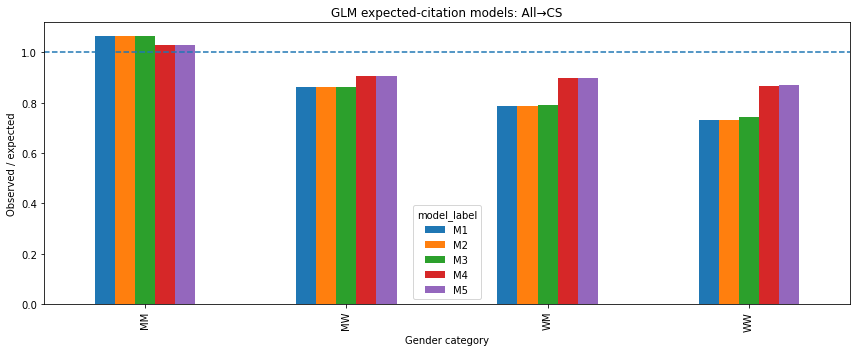

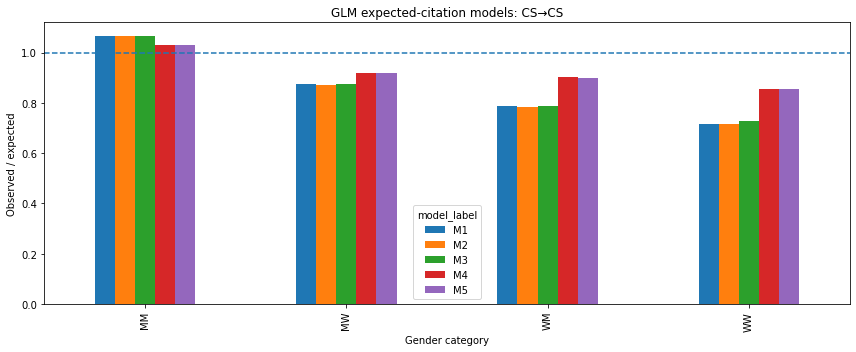

In [5]:
for sl in SLICE_ORDER:
    z = oe[oe["citation_slice"].eq(sl)].copy()
    z["model_label"] = z["model"].map(MODEL_LABELS)
    pivot = (
        z.pivot(index="gender_cat", columns="model_label", values="oe_ratio")
        .reindex(GENDER_CATEGORIES)
        [["M1", "M2", "M3", "M4", "M5"]]
    )
    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.axhline(1.0, linestyle="--")
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.set_title(f"GLM expected-citation models: {sl}")
    plt.tight_layout()
    safe = sl.replace("→", "_to_")
    plt.savefig(FIGURE_DIR / f"glm_oe_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()
    pivot.to_csv(TABLE_DIR / f"glm_oe_pivot_{safe}.csv")

## Full-Data Diagnostics

In [6]:
metric_rows = []

for (sl, model), g in predictions_full.groupby(["citation_slice", "model"], sort=False):
    row = evaluate_predictions(g)
    row["citation_slice"] = sl
    row["model"] = model
    row["model_label"] = MODEL_LABELS[model]
    metric_rows.append(row)

metrics_full = pd.DataFrame(metric_rows)
metrics_full["model_label"] = pd.Categorical(
    metrics_full["model_label"],
    categories=["M1", "M2", "M3", "M4", "M5"],
    ordered=True,
)
metrics_full = metrics_full.sort_values(["citation_slice", "model_label"]).reset_index(drop=True)

comparison_rows = []
for sl in SLICE_ORDER:
    z = metrics_full[metrics_full["citation_slice"].eq(sl)].copy()
    m1 = z[z["model_label"].eq("M1")].iloc[0]
    for _, r in z.iterrows():
        comparison_rows.append({
            "citation_slice": sl,
            "model": r["model"],
            "model_label": r["model_label"],
            "poisson_d2": r["poisson_d2"],
            "delta_poisson_d2_vs_M1": r["poisson_d2"] - m1["poisson_d2"],
            "mean_poisson_deviance": r["mean_poisson_deviance"],
            "poisson_deviance_reduction_pct_vs_M1":
                100 * (m1["mean_poisson_deviance"] - r["mean_poisson_deviance"])
                / m1["mean_poisson_deviance"],
            "mae": r["mae"],
            "mae_reduction_pct_vs_M1":
                100 * (m1["mae"] - r["mae"]) / m1["mae"],
            "median_absolute_error": r["median_absolute_error"],
            "median_ae_reduction_pct_vs_M1":
                100 * (m1["median_absolute_error"] - r["median_absolute_error"])
                / m1["median_absolute_error"],
        })

comparison_full = pd.DataFrame(comparison_rows)

calibration_parts = []
for (sl, model), g in predictions_full.groupby(["citation_slice", "model"], sort=False):
    c = calibration_deciles(g)
    c["citation_slice"] = sl
    c["model"] = model
    c["model_label"] = MODEL_LABELS[model]
    calibration_parts.append(c)

calibration_full = pd.concat(calibration_parts, ignore_index=True)

display(metrics_full)
display(comparison_full)

,n_papers,observed_total,expected_total,total_oe_ratio,mean_poisson_deviance,null_mean_poisson_deviance,poisson_d2,mae,median_absolute_error,citation_slice,model,model_label
0,1081363,"8,686,237.0000","8,686,237.0000",1.0000,26.4543,32.0198,0.1738,9.7484,5.1380,All→CS,M1_structural,M1
1,1081363,"8,686,237.0000","8,686,237.0000",1.0000,26.4590,32.0198,0.1737,9.7465,5.1203,All→CS,M2_direct_citation_network,M2
2,1081363,"8,686,237.0000","8,686,237.0000",1.0000,26.1802,32.0198,0.1824,9.7062,4.9093,All→CS,M3_bibliographic_coupling,M3
3,1081363,"8,686,237.0000","8,686,237.0000",1.0000,13.1707,32.0198,0.5887,6.5025,3.1300,All→CS,M4_cocitation,M4
4,1081363,"8,686,237.0000","8,686,237.0000",1.0000,13.1645,32.0198,0.5889,6.5057,3.1213,All→CS,M5_all_network_features,M5
5,1081363,"7,023,500.0000","7,023,500.0000",1.0000,21.6341,26.0251,0.1687,8.0390,4.3410,CS→CS,M1_structural,M1
6,1081363,"7,023,500.0000","7,023,500.0000",1.0000,21.5877,26.0251,0.1705,8.0227,4.2932,CS→CS,M2_direct_citation_network,M2
7,1081363,"7,023,500.0000","7,023,500.0000",1.0000,21.3551,26.0251,0.1794,7.9905,4.0781,CS→CS,M3_bibliographic_coupling,M3
8,1081363,"7,023,500.0000","7,023,500.0000",1.0000,10.6291,26.0251,0.5916,5.3115,2.5816,CS→CS,M4_cocitation,M4
9,1081363,"7,023,500.0000","7,023,500.0000",1.0000,10.5948,26.0251,0.5929,5.3043,2.5551,CS→CS,M5_all_network_features,M5


,citation_slice,model,model_label,poisson_d2,delta_poisson_d2_vs_M1,mean_poisson_deviance,poisson_deviance_reduction_pct_vs_M1,mae,mae_reduction_pct_vs_M1,median_absolute_error,median_ae_reduction_pct_vs_M1
0,All→CS,M1_structural,M1,0.1738,0.0000,26.4543,0.0000,9.7484,0.0000,5.1380,0.0000
1,All→CS,M2_direct_citation_network,M2,0.1737,-0.0001,26.4590,-0.0178,9.7465,0.0199,5.1203,0.3449
2,All→CS,M3_bibliographic_coupling,M3,0.1824,0.0086,26.1802,1.0361,9.7062,0.4325,4.9093,4.4506
3,All→CS,M4_cocitation,M4,0.5887,0.4149,13.1707,50.2132,6.5025,33.2966,3.1300,39.0803
4,All→CS,M5_all_network_features,M5,0.5889,0.4150,13.1645,50.2368,6.5057,33.2639,3.1213,39.2506
5,CS→CS,M1_structural,M1,0.1687,0.0000,21.6341,0.0000,8.0390,0.0000,4.3410,0.0000
6,CS→CS,M2_direct_citation_network,M2,0.1705,0.0018,21.5877,0.2145,8.0227,0.2028,4.2932,1.1010
7,CS→CS,M3_bibliographic_coupling,M3,0.1794,0.0107,21.3551,1.2897,7.9905,0.6034,4.0781,6.0553
8,CS→CS,M4_cocitation,M4,0.5916,0.4229,10.6291,50.8688,5.3115,33.9290,2.5816,40.5306
9,CS→CS,M5_all_network_features,M5,0.5929,0.4242,10.5948,51.0273,5.3043,34.0187,2.5551,41.1392


## Full-Data Diagnostic Figures

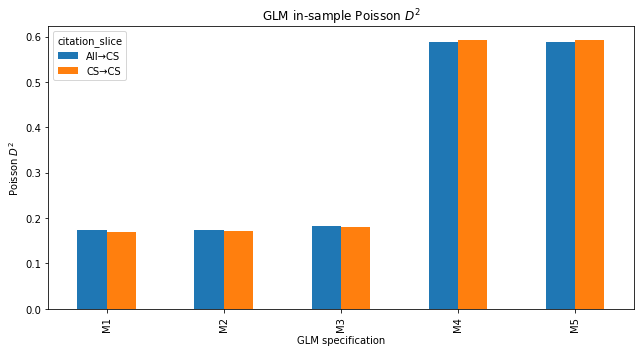

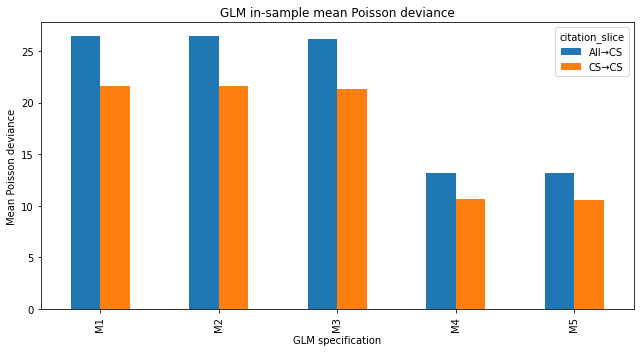

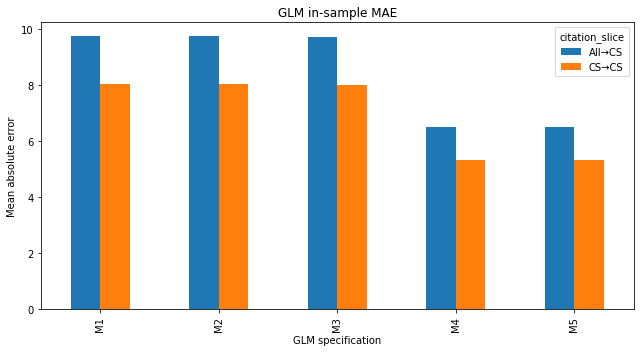

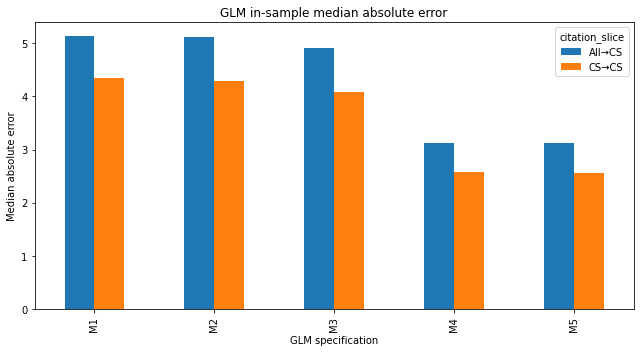

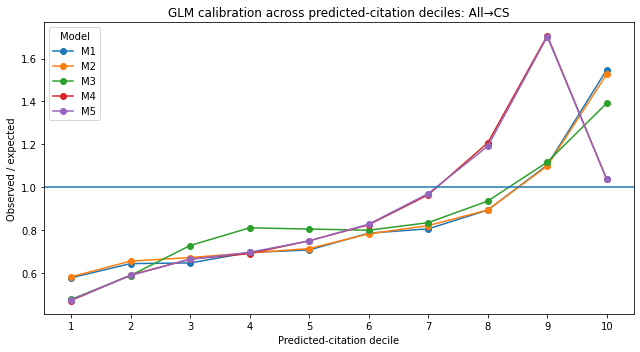

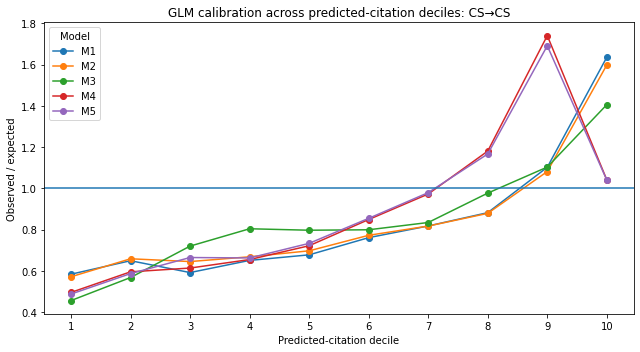

In [7]:
for metric, ylabel, filename, title in [
    ("poisson_d2", "Poisson $D^2$", "glm_poisson_d2_by_model.png", "GLM in-sample Poisson $D^2$"),
    ("mean_poisson_deviance", "Mean Poisson deviance", "glm_mean_poisson_deviance_by_model.png", "GLM in-sample mean Poisson deviance"),
    ("mae", "Mean absolute error", "glm_mae_by_model.png", "GLM in-sample MAE"),
    ("median_absolute_error", "Median absolute error", "glm_median_absolute_error_by_model.png", "GLM in-sample median absolute error"),
]:
    piv = (
        metrics_full.pivot(index="model_label", columns="citation_slice", values=metric)
        .reindex(["M1", "M2", "M3", "M4", "M5"])
    )
    ax = piv.plot(kind="bar", figsize=(9, 5))
    ax.set_xlabel("GLM specification")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

for sl in SLICE_ORDER:
    z = calibration_full[calibration_full["citation_slice"].eq(sl)].copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    for model in MODEL_ORDER:
        q = z[z["model"].eq(model)].sort_values("predicted_decile")
        ax.plot(q["predicted_decile"], q["oe_ratio"], marker="o", label=MODEL_LABELS[model])
    ax.axhline(1)
    ax.set_xlabel("Predicted-citation decile")
    ax.set_ylabel("Observed / expected")
    ax.set_xticks(range(1, 11))
    ax.set_title(f"GLM calibration across predicted-citation deciles: {sl}")
    ax.legend(title="Model")
    plt.tight_layout()
    safe = sl.replace("→", "_to_")
    plt.savefig(FIGURE_DIR / f"glm_calibration_deciles_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 80/20 Holdout Split

In [8]:
paper_ids = base["paper_id"].astype(str).to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
permuted = rng.permutation(paper_ids)
n_test = int(round(TEST_SIZE * len(permuted)))
test_ids = set(permuted[:n_test])
train_ids = set(permuted[n_test:])

split_rows = []
for sl, df in [("All→CS", features_all), ("CS→CS", features_cs)]:
    for split_name, ids in [("train", train_ids), ("test", test_ids)]:
        z = df[df["paper_id"].isin(ids)]
        split_rows.append({
            "citation_slice": sl,
            "split": split_name,
            "n_papers": len(z),
            "paper_share": len(z) / len(df),
            "observed_total": z["observed"].sum(),
            "observed_mean": z["observed"].mean(),
            "observed_median": z["observed"].median(),
            "zero_citation_share": (z["observed"] == 0).mean(),
            "MM_share": z["gender_cat"].eq("MM").mean(),
            "MW_share": z["gender_cat"].eq("MW").mean(),
            "WM_share": z["gender_cat"].eq("WM").mean(),
            "WW_share": z["gender_cat"].eq("WW").mean(),
        })

split_summary = pd.DataFrame(split_rows)
display(split_summary)

,citation_slice,split,n_papers,paper_share,observed_total,observed_mean,observed_median,zero_citation_share,MM_share,MW_share,WM_share,WW_share
0,All→CS,train,865090,0.8000,"6,989,370.0000",8.0794,1.0000,0.3452,0.7308,0.0904,0.1274,0.0515
1,All→CS,test,216273,0.2000,"1,696,867.0000",7.8459,1.0000,0.3452,0.7326,0.0889,0.1273,0.0512
2,CS→CS,train,865090,0.8000,"5,647,739.0000",6.5285,1.0000,0.4030,0.7308,0.0904,0.1274,0.0515
3,CS→CS,test,216273,0.2000,"1,375,761.0000",6.3612,1.0000,0.4025,0.7326,0.0889,0.1273,0.0512


## Holdout Validation

In [9]:
metric_rows = []
prediction_parts = []
oe_parts = []

for model, numeric_features in MODEL_SPECS.items():
    for sl, df in [("All→CS", features_all), ("CS→CS", features_cs)]:
        train, test, pipe, train_scale = fit_train_predict_holdout(
            df,
            train_ids,
            test_ids,
            CATEGORICAL,
            numeric_features,
        )

        for split_name, z in [("train", train), ("test", test)]:
            row = evaluate_predictions(z)
            row.update({
                "model": model,
                "model_label": MODEL_LABELS[model],
                "citation_slice": sl,
                "split": split_name,
                "train_calibration_factor": train_scale,
                "n_numeric_features": len(numeric_features),
            })
            metric_rows.append(row)

            prediction_parts.append(
                z[["paper_id", "gender_cat", "observed", "expected", "split"]].assign(
                    model=model,
                    model_label=MODEL_LABELS[model],
                    citation_slice=sl,
                )
            )

            gender_oe = (
                z.groupby("gender_cat")
                .agg(
                    n_papers=("paper_id", "nunique"),
                    observed_citations=("observed", "sum"),
                    expected_citations=("expected", "sum"),
                )
                .reindex(GENDER_CATEGORIES)
                .reset_index()
            )
            gender_oe["oe_ratio"] = (
                gender_oe["observed_citations"]
                / gender_oe["expected_citations"].replace(0, np.nan)
            )
            gender_oe["pct_diff_from_expected"] = (gender_oe["oe_ratio"] - 1) * 100
            gender_oe["model"] = model
            gender_oe["model_label"] = MODEL_LABELS[model]
            gender_oe["citation_slice"] = sl
            gender_oe["split"] = split_name
            oe_parts.append(gender_oe)

metrics_holdout = pd.DataFrame(metric_rows)
predictions_holdout = pd.concat(prediction_parts, ignore_index=True)
holdout_oe = pd.concat(oe_parts, ignore_index=True)

metrics_holdout["model_label"] = pd.Categorical(
    metrics_holdout["model_label"],
    categories=["M1", "M2", "M3", "M4", "M5"],
    ordered=True,
)
metrics_holdout["split"] = pd.Categorical(
    metrics_holdout["split"],
    categories=["train", "test"],
    ordered=True,
)
metrics_holdout = metrics_holdout.sort_values(
    ["citation_slice", "model_label", "split"]
).reset_index(drop=True)

display(metrics_holdout)

,n_papers,observed_total,expected_total,total_oe_ratio,mean_poisson_deviance,null_mean_poisson_deviance,poisson_d2,mae,median_absolute_error,model,model_label,citation_slice,split,train_calibration_factor,n_numeric_features
0,865090,"6,989,370.0000","6,989,370.0000",1.0000,26.9064,32.5563,0.1735,9.8192,5.1653,M1_structural,M1,All→CS,train,1.0000,1
1,216273,"1,696,867.0000","1,746,049.0113",0.9718,24.5781,29.8682,0.1771,9.5865,5.1581,M1_structural,M1,All→CS,test,1.0000,1
2,865090,"6,989,370.0000","6,989,370.0000",1.0000,26.9107,32.5563,0.1734,9.8175,5.1473,M2_direct_citation_network,M2,All→CS,train,1.0000,2
3,216273,"1,696,867.0000","1,746,021.6643",0.9718,24.5931,29.8682,0.1766,9.5844,5.1359,M2_direct_citation_network,M2,All→CS,test,1.0000,2
4,865090,"6,989,370.0000","6,989,370.0000",1.0000,26.6293,32.5563,0.1821,9.7774,4.9171,M3_bibliographic_coupling,M3,All→CS,train,1.0000,5
5,216273,"1,696,867.0000","1,744,356.3029",0.9728,24.3491,29.8682,0.1848,9.5420,4.9171,M3_bibliographic_coupling,M3,All→CS,test,1.0000,5
6,865090,"6,989,370.0000","6,989,370.0000",1.0000,13.2603,32.5563,0.5927,6.5377,3.1316,M4_cocitation,M4,All→CS,train,1.0000,5
7,216273,"1,696,867.0000","1,719,645.4631",0.9868,12.8093,29.8682,0.5711,6.3931,3.1317,M4_cocitation,M4,All→CS,test,1.0000,5
8,865090,"6,989,370.0000","6,989,370.0000",1.0000,13.2557,32.5563,0.5928,6.5414,3.1215,M5_all_network_features,M5,All→CS,train,1.0000,10
9,216273,"1,696,867.0000","1,719,341.0317",0.9869,12.8013,29.8682,0.5714,6.3953,3.1212,M5_all_network_features,M5,All→CS,test,1.0000,10


## Holdout Calibration and Generalization

In [10]:
metric_names = [
    "mean_poisson_deviance",
    "poisson_d2",
    "mae",
    "median_absolute_error",
    "total_oe_ratio",
]

wide = metrics_holdout.pivot_table(
    index=["citation_slice", "model", "model_label"],
    columns="split",
    values=metric_names,
    observed=False,
)
wide.columns = [f"{metric}_{split}" for metric, split in wide.columns]
wide = wide.reset_index()

for metric in ["mean_poisson_deviance", "poisson_d2", "mae", "median_absolute_error"]:
    wide[f"{metric}_test_minus_train"] = wide[f"{metric}_test"] - wide[f"{metric}_train"]

test_predictions = predictions_holdout[predictions_holdout["split"].eq("test")].copy()

calibration_parts = []
for (sl, model), g in test_predictions.groupby(["citation_slice", "model"], sort=False):
    c = calibration_deciles(g)
    c["citation_slice"] = sl
    c["model"] = model
    c["model_label"] = MODEL_LABELS[model]
    calibration_parts.append(c)

test_calibration = pd.concat(calibration_parts, ignore_index=True)
test_metrics = metrics_holdout[metrics_holdout["split"].eq("test")].copy()
test_oe = holdout_oe[holdout_oe["split"].eq("test")].copy()

full_small = metrics_full[[
    "citation_slice",
    "model",
    "model_label",
    "poisson_d2",
    "mean_poisson_deviance",
    "mae",
    "median_absolute_error",
]].rename(columns={
    "poisson_d2": "full_in_sample_poisson_d2",
    "mean_poisson_deviance": "full_in_sample_poisson_deviance",
    "mae": "full_in_sample_mae",
    "median_absolute_error": "full_in_sample_median_ae",
})

holdout_small = test_metrics[[
    "citation_slice",
    "model",
    "model_label",
    "poisson_d2",
    "mean_poisson_deviance",
    "mae",
    "median_absolute_error",
]].rename(columns={
    "poisson_d2": "holdout_test_poisson_d2",
    "mean_poisson_deviance": "holdout_test_poisson_deviance",
    "mae": "holdout_test_mae",
    "median_absolute_error": "holdout_test_median_ae",
})

full_vs_holdout = full_small.merge(
    holdout_small,
    on=["citation_slice", "model", "model_label"],
    how="inner",
)

display(wide)
display(test_calibration.head(20))
display(full_vs_holdout)

,citation_slice,model,model_label,mae_train,mae_test,mean_poisson_deviance_train,mean_poisson_deviance_test,median_absolute_error_train,median_absolute_error_test,poisson_d2_train,poisson_d2_test,total_oe_ratio_train,total_oe_ratio_test,mean_poisson_deviance_test_minus_train,poisson_d2_test_minus_train,mae_test_minus_train,median_absolute_error_test_minus_train
0,All→CS,M1_structural,M1,9.8192,9.5865,26.9064,24.5781,5.1653,5.1581,0.1735,0.1771,1.0000,0.9718,-2.3283,0.0036,-0.2327,-0.0071
1,All→CS,M2_direct_citation_network,M2,9.8175,9.5844,26.9107,24.5931,5.1473,5.1359,0.1734,0.1766,1.0000,0.9718,-2.3176,0.0032,-0.2331,-0.0113
2,All→CS,M3_bibliographic_coupling,M3,9.7774,9.5420,26.6293,24.3491,4.9171,4.9171,0.1821,0.1848,1.0000,0.9728,-2.2802,0.0027,-0.2354,0.0000
3,All→CS,M4_cocitation,M4,6.5377,6.3931,13.2603,12.8093,3.1316,3.1317,0.5927,0.5711,1.0000,0.9868,-0.4510,-0.0216,-0.1446,0.0001
4,All→CS,M5_all_network_features,M5,6.5414,6.3953,13.2557,12.8013,3.1215,3.1212,0.5928,0.5714,1.0000,0.9869,-0.4544,-0.0214,-0.1460,-0.0003
5,CS→CS,M1_structural,M1,8.0907,7.9201,21.9628,20.2764,4.3658,4.3635,0.1682,0.1728,1.0000,0.9751,-1.6864,0.0046,-0.1706,-0.0023
6,CS→CS,M2_direct_citation_network,M2,8.0744,7.9036,21.9139,20.2459,4.3084,4.2998,0.1700,0.1740,1.0000,0.9751,-1.6681,0.0040,-0.1708,-0.0086
7,CS→CS,M3_bibliographic_coupling,M3,8.0420,7.8705,21.6818,20.0314,4.0935,4.0967,0.1788,0.1828,1.0000,0.9762,-1.6505,0.0040,-0.1715,0.0032
8,CS→CS,M4_cocitation,M4,5.3442,5.2082,10.7444,10.1661,2.5859,2.5859,0.5931,0.5853,1.0000,0.9887,-0.5784,-0.0078,-0.1360,0.0000
9,CS→CS,M5_all_network_features,M5,5.3368,5.2020,10.7110,10.1317,2.5597,2.5596,0.5943,0.5867,1.0000,0.9893,-0.5793,-0.0077,-0.1349,-0.0002


,predicted_decile,n_papers,observed_total,expected_total,observed_mean,expected_mean,oe_ratio,citation_slice,model,model_label
0,1,21628,"38,057.0000","63,572.2693",1.7596,2.9394,0.5986,All→CS,M1_structural,M1
1,2,21627,"57,429.0000","86,333.5388",2.6554,3.9919,0.6652,All→CS,M1_structural,M1
2,3,21627,"70,873.0000","102,179.1359",3.2771,4.7246,0.6936,All→CS,M1_structural,M1
3,4,21627,"78,578.0000","117,235.4874",3.6333,5.4208,0.6703,All→CS,M1_structural,M1
4,5,21628,"96,095.0000","133,728.4093",4.4431,6.1831,0.7186,All→CS,M1_structural,M1
5,6,21627,"112,137.0000","153,907.1724",5.1850,7.1164,0.7286,All→CS,M1_structural,M1
6,7,21627,"143,328.0000","178,745.0338",6.6273,8.2649,0.8019,All→CS,M1_structural,M1
7,8,21627,"190,922.0000","212,195.0235",8.8279,9.8116,0.8997,All→CS,M1_structural,M1
8,9,21627,"281,004.0000","272,675.3350",12.9932,12.6081,1.0305,All→CS,M1_structural,M1
9,10,21628,"628,444.0000","425,477.6058",29.0570,19.6725,1.4770,All→CS,M1_structural,M1


,citation_slice,model,model_label,full_in_sample_poisson_d2,full_in_sample_poisson_deviance,full_in_sample_mae,full_in_sample_median_ae,holdout_test_poisson_d2,holdout_test_poisson_deviance,holdout_test_mae,holdout_test_median_ae
0,All→CS,M1_structural,M1,0.1738,26.4543,9.7484,5.1380,0.1771,24.5781,9.5865,5.1581
1,All→CS,M2_direct_citation_network,M2,0.1737,26.4590,9.7465,5.1203,0.1766,24.5931,9.5844,5.1359
2,All→CS,M3_bibliographic_coupling,M3,0.1824,26.1802,9.7062,4.9093,0.1848,24.3491,9.5420,4.9171
3,All→CS,M4_cocitation,M4,0.5887,13.1707,6.5025,3.1300,0.5711,12.8093,6.3931,3.1317
4,All→CS,M5_all_network_features,M5,0.5889,13.1645,6.5057,3.1213,0.5714,12.8013,6.3953,3.1212
5,CS→CS,M1_structural,M1,0.1687,21.6341,8.0390,4.3410,0.1728,20.2764,7.9201,4.3635
6,CS→CS,M2_direct_citation_network,M2,0.1705,21.5877,8.0227,4.2932,0.1740,20.2459,7.9036,4.2998
7,CS→CS,M3_bibliographic_coupling,M3,0.1794,21.3551,7.9905,4.0781,0.1828,20.0314,7.8705,4.0967
8,CS→CS,M4_cocitation,M4,0.5916,10.6291,5.3115,2.5816,0.5853,10.1661,5.2082,2.5859
9,CS→CS,M5_all_network_features,M5,0.5929,10.5948,5.3043,2.5551,0.5867,10.1317,5.2020,2.5596


## Holdout Figures

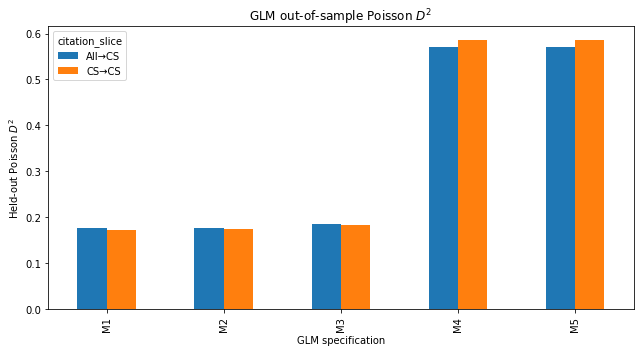

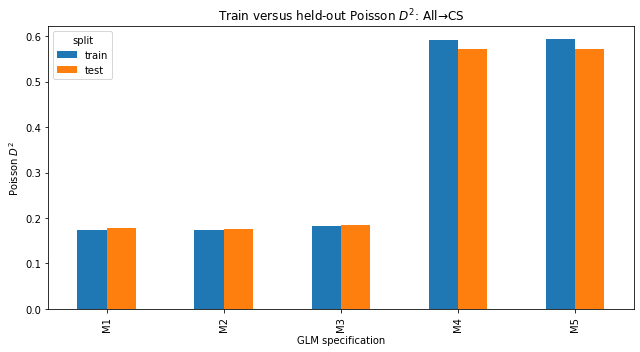

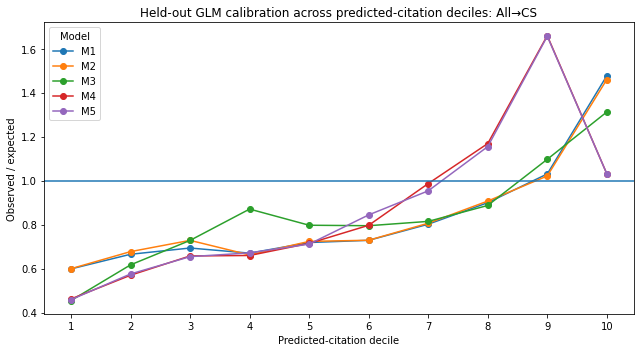

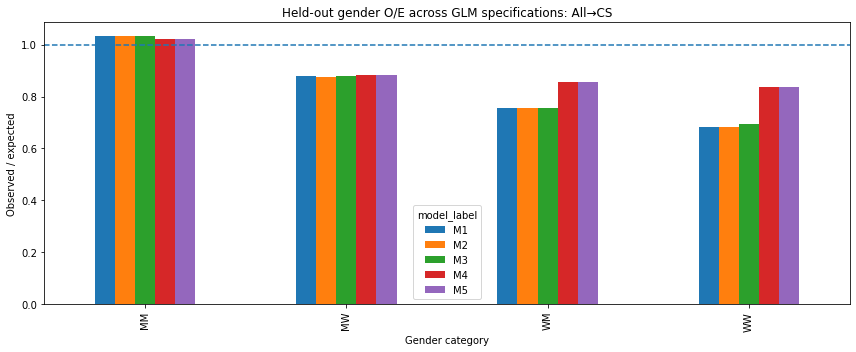

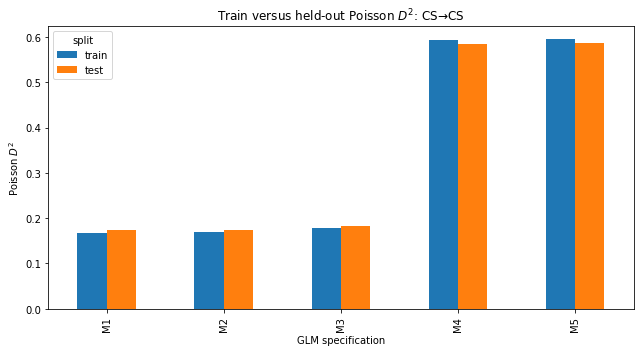

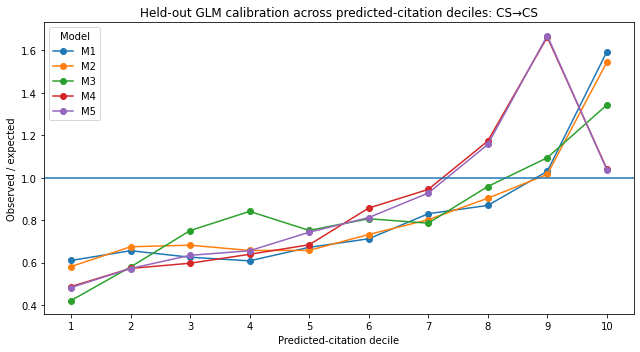

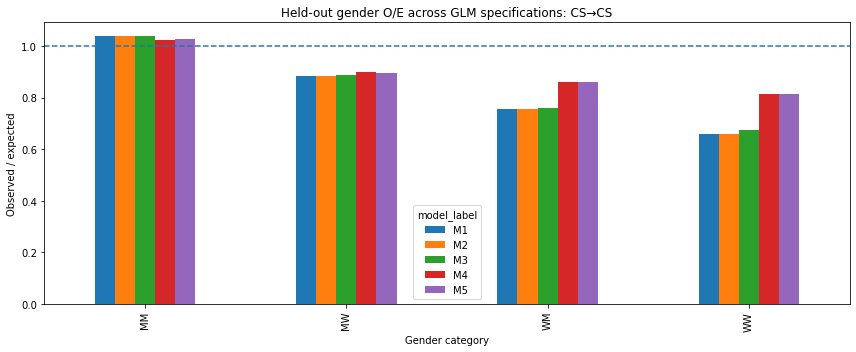

In [11]:
piv = (
    test_metrics.pivot(index="model_label", columns="citation_slice", values="poisson_d2")
    .reindex(["M1", "M2", "M3", "M4", "M5"])
)
ax = piv.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("GLM specification")
ax.set_ylabel("Held-out Poisson $D^2$")
ax.set_title("GLM out-of-sample Poisson $D^2$")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "glm_holdout_test_poisson_d2_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

for sl in SLICE_ORDER:
    safe = sl.replace("→", "_to_")

    z = metrics_holdout[metrics_holdout["citation_slice"].eq(sl)].copy()
    piv = (
        z.pivot(index="model_label", columns="split", values="poisson_d2")
        .reindex(["M1", "M2", "M3", "M4", "M5"])
    )
    ax = piv.plot(kind="bar", figsize=(9, 5))
    ax.set_xlabel("GLM specification")
    ax.set_ylabel("Poisson $D^2$")
    ax.set_title(f"Train versus held-out Poisson $D^2$: {sl}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"glm_holdout_train_vs_test_d2_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

    zc = test_calibration[test_calibration["citation_slice"].eq(sl)].copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    for model in MODEL_ORDER:
        q = zc[zc["model"].eq(model)].sort_values("predicted_decile")
        ax.plot(q["predicted_decile"], q["oe_ratio"], marker="o", label=MODEL_LABELS[model])
    ax.axhline(1)
    ax.set_xlabel("Predicted-citation decile")
    ax.set_ylabel("Observed / expected")
    ax.set_xticks(range(1, 11))
    ax.set_title(f"Held-out GLM calibration across predicted-citation deciles: {sl}")
    ax.legend(title="Model")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"glm_holdout_calibration_deciles_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

    zoe = test_oe[test_oe["citation_slice"].eq(sl)].copy()
    piv = (
        zoe.pivot(index="gender_cat", columns="model_label", values="oe_ratio")
        .reindex(GENDER_CATEGORIES)
        [["M1", "M2", "M3", "M4", "M5"]]
    )
    ax = piv.plot(kind="bar", figsize=(12, 5))
    ax.axhline(1, linestyle="--")
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.set_title(f"Held-out gender O/E across GLM specifications: {sl}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"glm_holdout_gender_oe_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Save Results

In [12]:
feature_specs.to_csv(TABLE_DIR / "glm_representation_model_feature_specs.csv", index=False)
oe.to_csv(TABLE_DIR / "glm_representation_specific_oe_by_gender.csv", index=False)
metrics_full.to_csv(TABLE_DIR / "glm_model_diagnostics_metrics.csv", index=False)
comparison_full.to_csv(TABLE_DIR / "glm_model_diagnostics_improvement_vs_m1.csv", index=False)
calibration_full.to_csv(TABLE_DIR / "glm_calibration_by_predicted_decile.csv", index=False)
split_summary.to_csv(TABLE_DIR / "glm_holdout_split_summary.csv", index=False)
metrics_holdout.to_csv(TABLE_DIR / "glm_holdout_metrics.csv", index=False)
wide.to_csv(TABLE_DIR / "glm_holdout_generalization_gaps.csv", index=False)
holdout_oe.to_csv(TABLE_DIR / "glm_holdout_oe_by_gender.csv", index=False)
test_calibration.to_csv(TABLE_DIR / "glm_holdout_test_calibration_by_predicted_decile.csv", index=False)
full_vs_holdout.to_csv(TABLE_DIR / "glm_full_vs_holdout_metrics.csv", index=False)
predictions_full.to_pickle(DATA_OUTPUT_DIR / "glm_representation_specific_paper_predictions.pkl")
predictions_holdout.to_pickle(DATA_OUTPUT_DIR / "glm_holdout_paper_predictions.pkl")